# Ordinal Logistic Regression: Predicting Support for AI Adoption

**Research Question:** What predicts whether people support companies adopting generative AI?

**Target variable:** `support_company` — 5-point Likert scale  
1 = Strongly oppose → 5 = Strongly support

**Model:** Ordered Logit (Proportional Odds Model)  
**Dataset:** Borwein, Magistro, Alvarez, Bonikowski & Loewen — *PNAS Nexus*

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.iolib.summary2 import summary_col

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('AI.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3049, 13)


,Number,risks_AI_avg,support_company,gender_bin,objective_threat,trait_risk,educ_short,percent_job_gain,age_group,education,country,manipulation_check2,weight
0,1,4.0,4.0,Men,NaN,certain,0,100%,45 to 64,HS or less,US,Pass,0.2703
1,2,4.0,2.0,NaN,0.200000,certain,1,30%,45 to 64,Postgrad,US,Pass,0.2709
2,3,3.0,4.0,Men,NaN,certain,0,70%,45 to 64,HS or less,US,Pass,0.6464
3,4,2.5,3.0,Men,0.466667,certain,0,100%,30 to 44,HS or less,US,Pass,2.7281
4,5,3.0,4.0,Men,NaN,certain,0,30%,65 or older,Some college,US,Fail,0.8643


In [3]:
# Missing value overview for variables of interest
cols_of_interest = ['support_company', 'risks_AI_avg', 'gender_bin', 'trait_risk',
                    'objective_threat', 'percent_job_gain', 'education', 'age_group', 'weight']
missing = df[cols_of_interest].isnull().sum()
pct     = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing N': missing, 'Missing %': pct})

,Missing N,Missing %
support_company,360,11.8
risks_AI_avg,0,0.0
gender_bin,42,1.4
trait_risk,0,0.0
objective_threat,1449,47.5
percent_job_gain,0,0.0
education,0,0.0
age_group,0,0.0
weight,0,0.0


## 3. Exploratory Data Analysis

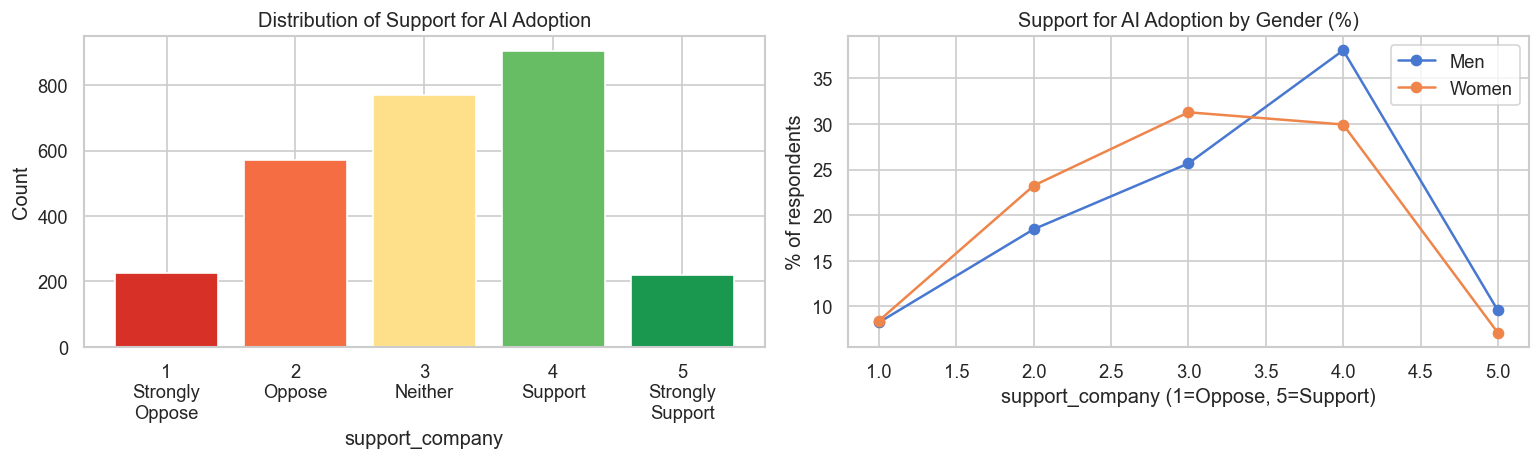

In [4]:
# Distribution of support_company
labels_map = {1: '1\nStrongly\nOppose', 2: '2\nOppose',
              3: '3\nNeither', 4: '4\nSupport', 5: '5\nStrongly\nSupport'}
counts = df['support_company'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bar_colors = ['#d73027','#f46d43','#fee08b','#66bd63','#1a9850']
axes[0].bar([labels_map[k] for k in counts.index], counts.values, color=bar_colors)
axes[0].set_title('Distribution of Support for AI Adoption')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('support_company')

# By gender
gender_support = df.dropna(subset=['gender_bin','support_company'])
for label, grp in gender_support.groupby('gender_bin'):
    counts_g = grp['support_company'].value_counts(normalize=True).sort_index() * 100
    axes[1].plot(counts_g.index, counts_g.values, marker='o', label=label)
axes[1].set_title('Support for AI Adoption by Gender (%)')
axes[1].set_xlabel('support_company (1=Oppose, 5=Support)')
axes[1].set_ylabel('% of respondents')
axes[1].legend()

plt.tight_layout()
plt.show()

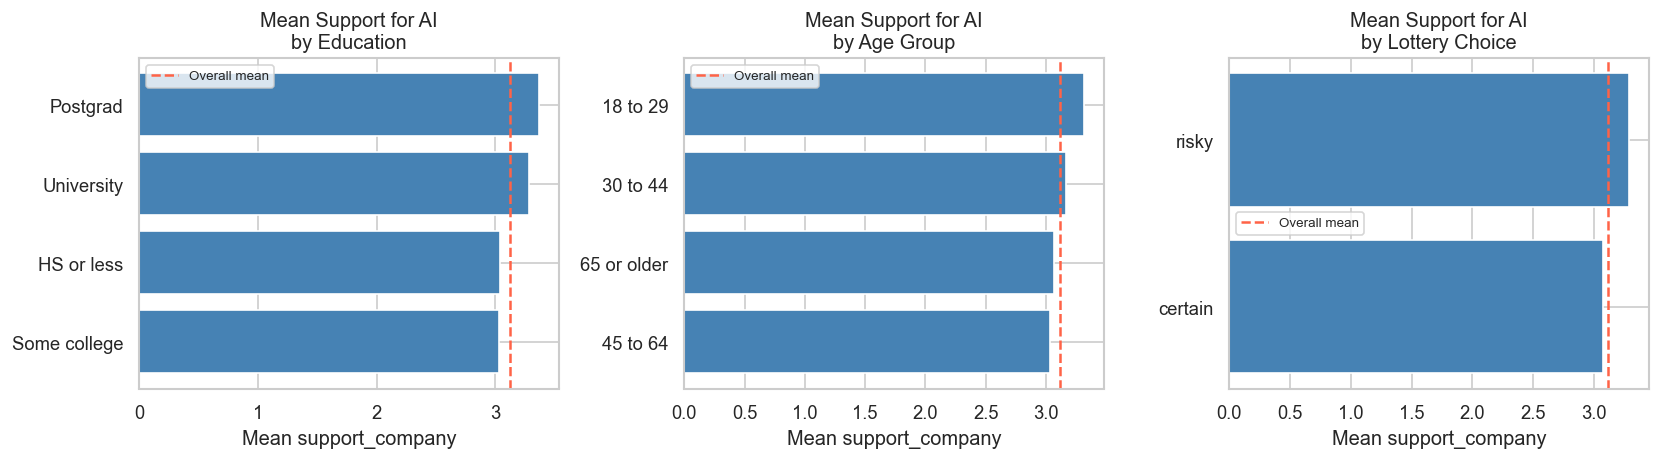

In [5]:
# Mean support by key categorical predictors
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ['education', 'age_group', 'trait_risk'],
    ['Education', 'Age Group', 'Lottery Choice']
):
    means = df.groupby(col)['support_company'].mean().sort_values()
    ax.barh(means.index, means.values, color='steelblue')
    ax.axvline(df['support_company'].mean(), color='tomato', ls='--', label='Overall mean')
    ax.set_title(f'Mean Support for AI\nby {title}')
    ax.set_xlabel('Mean support_company')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

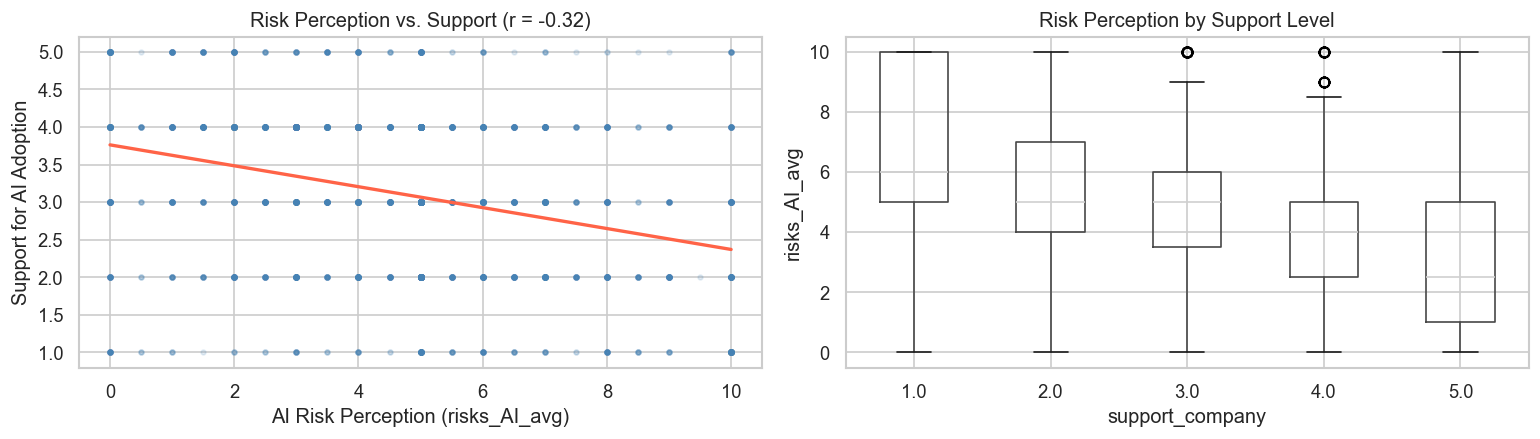

In [6]:
# Relationship between AI risk perception and support (key predictor)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter with regression line
tmp = df[['risks_AI_avg','support_company']].dropna()
axes[0].scatter(tmp['risks_AI_avg'], tmp['support_company'],
                alpha=0.15, s=8, color='steelblue')
m, b = np.polyfit(tmp['risks_AI_avg'], tmp['support_company'], 1)
x_line = np.linspace(0, 10, 100)
axes[0].plot(x_line, m*x_line + b, color='tomato', lw=2)
axes[0].set_xlabel('AI Risk Perception (risks_AI_avg)')
axes[0].set_ylabel('Support for AI Adoption')
axes[0].set_title(f'Risk Perception vs. Support (r = {tmp.corr().iloc[0,1]:.2f})')

# Box plots by support level
df.dropna(subset=['support_company','risks_AI_avg']).boxplot(
    column='risks_AI_avg', by='support_company', ax=axes[1])
axes[1].set_title('Risk Perception by Support Level')
axes[1].set_xlabel('support_company')
axes[1].set_ylabel('risks_AI_avg')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 4. Data Preparation

**Encoding decisions:**
- `support_company`: cast to ordered `pd.Categorical` (required by `OrderedModel`)
- `education`: 4-level ordered variable → dummy-encode (ref = *HS or less*)
- `age_group`: 4 groups → dummy-encode (ref = *18 to 29*)
- `percent_job_gain`: strip `%`, treat as numeric
- `gender_bin`: binary dummy (1 = Women, ref = Men)
- `trait_risk`: binary dummy (1 = risky, ref = certain)

**Three analysis samples** (same strategy as OLS notebook):
| Sample | Description |
|--------|-------------|
| M1 — Baseline | All non-missing on core predictors |
| M2 — + Objective Threat | Subset with `objective_threat` available |
| M3 — Manip. Check Passed | Robustness: attentive respondents only |

In [7]:
# ── Feature engineering ───────────────────────────────────────────────────────
df['percent_job_gain_num'] = df['percent_job_gain'].str.replace('%','').astype(float)
df['female']      = (df['gender_bin'] == 'Women').astype(float)
df['trait_risky'] = (df['trait_risk']  == 'risky').astype(float)
df['manip_pass']  = (df['manipulation_check2'] == 'Pass').astype(float)

# Education dummies (ref = HS or less)
df['educ_somecollege'] = (df['education'] == 'Some college').astype(float)
df['educ_university']  = (df['education'] == 'University').astype(float)
df['educ_postgrad']    = (df['education'] == 'Postgrad').astype(float)

# Age group dummies (ref = 18 to 29)
df['age_30_44']  = (df['age_group'] == '30 to 44').astype(float)
df['age_45_64']  = (df['age_group'] == '45 to 64').astype(float)
df['age_65plus'] = (df['age_group'] == '65 or older').astype(float)

# Ordered categorical target (required by OrderedModel)
# .where() keeps the full index length; NaNs remain NaN instead of being dropped
df['support_ord'] = pd.Categorical(
    df['support_company'].where(df['support_company'].notna()).map(
        lambda x: int(x) if pd.notna(x) else np.nan
    ),
    categories=[1, 2, 3, 4, 5],
    ordered=True
)

print('Feature engineering complete.')
df[['support_ord','female','trait_risky','educ_university','percent_job_gain_num']].head()

Feature engineering complete.


,support_ord,female,trait_risky,educ_university,percent_job_gain_num
0,4,0.0,0.0,0.0,100.0
1,2,0.0,0.0,0.0,30.0
2,4,0.0,0.0,0.0,70.0
3,3,0.0,0.0,0.0,100.0
4,4,0.0,0.0,0.0,30.0


In [8]:
# ── Define predictor lists ────────────────────────────────────────────────────
BASE_PREDICTORS = [
    'risks_AI_avg',
    'female',
    'trait_risky',
    'educ_somecollege', 'educ_university', 'educ_postgrad',
    'percent_job_gain_num',
    'age_30_44', 'age_45_64', 'age_65plus'
]

TARGET = 'support_ord'
NEED_COLS = [TARGET] + BASE_PREDICTORS + ['weight', 'objective_threat', 'manip_pass']

# Rebuild support_ord on the full dataframe before subsetting
df[TARGET] = pd.Categorical(
    df['support_company'].where(df['support_company'].notna()).map(
        lambda x: int(x) if pd.notna(x) else np.nan
    ),
    categories=[1, 2, 3, 4, 5], ordered=True
)

In [9]:
# ── Sample 1: Baseline ────────────────────────────────────────────────────────
df_m1 = df[[TARGET] + BASE_PREDICTORS + ['weight']].dropna()
df_m1[TARGET] = pd.Categorical(df_m1[TARGET], categories=[1,2,3,4,5], ordered=True)
print(f'M1 N = {len(df_m1):,}')

# ── Sample 2: + Objective Threat ──────────────────────────────────────────────
df_m2 = df[[TARGET] + BASE_PREDICTORS + ['weight', 'objective_threat']].dropna()
df_m2[TARGET] = pd.Categorical(df_m2[TARGET], categories=[1,2,3,4,5], ordered=True)
print(f'M2 N = {len(df_m2):,}')

# ── Sample 3: Manipulation check passed ──────────────────────────────────────
df_m3 = df[[TARGET] + BASE_PREDICTORS + ['weight', 'manip_pass']].dropna()
df_m3 = df_m3[df_m3['manip_pass'] == 1].drop(columns='manip_pass')
df_m3[TARGET] = pd.Categorical(df_m3[TARGET], categories=[1,2,3,4,5], ordered=True)
print(f'M3 N = {len(df_m3):,}')

M1 N = 2,689
M2 N = 1,436
M3 N = 1,641


## 5. Ordered Logit Models

### Why Ordered Logit (not OLS or multinomial)?
- `support_company` is ordinal (1 < 2 < 3 < 4 < 5) — the order matters, but equal intervals are not guaranteed.
- **OLS** ignores the ordinal nature and can predict out-of-range values.
- **Multinomial logit** ignores the ordering, wasting statistical information.
- **Ordered logit** (proportional odds model) respects both the ordering and the categorical nature.

### Proportional Odds Assumption
The model assumes the effect of each predictor is **the same across all K−1 thresholds** (i.e., the log-odds ratio is constant). We test this with a Brant test after estimation.

In [10]:
# ── Model 1: Baseline ─────────────────────────────────────────────────────────
X1 = df_m1[BASE_PREDICTORS]
y1 = df_m1[TARGET]

m1 = OrderedModel(y1, X1, distr='logit')
res1 = m1.fit(method='bfgs', disp=False)
print(res1.summary())

                             OrderedModel Results                             
Dep. Variable:            support_ord   Log-Likelihood:                -3687.3
Model:                   OrderedModel   AIC:                             7403.
Method:            Maximum Likelihood   BIC:                             7485.
Date:                Mon, 16 Mar 2026                                         
Time:                        07:36:17                                         
No. Observations:                2689                                         
Df Residuals:                    2675                                         
Df Model:                          10                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
risks_AI_avg            -0.2504      0.016    -16.151      0.000      -0.281      -0.220
female                

In [11]:
# ── Model 2: + Objective Threat ───────────────────────────────────────────────
X2 = df_m2[BASE_PREDICTORS + ['objective_threat']]
y2 = df_m2[TARGET]

m2 = OrderedModel(y2, X2, distr='logit')
res2 = m2.fit(method='bfgs', disp=False)
print(res2.summary())

                             OrderedModel Results                             
Dep. Variable:            support_ord   Log-Likelihood:                -1948.0
Model:                   OrderedModel   AIC:                             3926.
Method:            Maximum Likelihood   BIC:                             4005.
Date:                Mon, 16 Mar 2026                                         
Time:                        07:36:17                                         
No. Observations:                1436                                         
Df Residuals:                    1421                                         
Df Model:                          11                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
risks_AI_avg            -0.2319      0.021    -10.949      0.000      -0.273      -0.190
female                

In [12]:
# ── Model 3: Manipulation Check Passed ───────────────────────────────────────
X3 = df_m3[BASE_PREDICTORS]
y3 = df_m3[TARGET]

m3 = OrderedModel(y3, X3, distr='logit')
res3 = m3.fit(method='bfgs', disp=False)
print(res3.summary())

                             OrderedModel Results                             
Dep. Variable:            support_ord   Log-Likelihood:                -2182.1
Model:                   OrderedModel   AIC:                             4392.
Method:            Maximum Likelihood   BIC:                             4468.
Date:                Mon, 16 Mar 2026                                         
Time:                        07:36:17                                         
No. Observations:                1641                                         
Df Residuals:                    1627                                         
Df Model:                          10                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
risks_AI_avg            -0.2783      0.021    -13.561      0.000      -0.319      -0.238
female                

## 6. Odds Ratios

Ordered logit coefficients are **log-odds**. Exponentiating gives **odds ratios (ORs)**:
- OR > 1 → predictor increases the odds of being in a *higher* support category
- OR < 1 → predictor decreases those odds
- OR = 1 → no effect

In [13]:
def odds_ratio_table(result, label):
    """Extract predictor coefficients only (exclude threshold parameters)."""
    params = result.params
    conf   = result.conf_int()
    pvals  = result.pvalues

    # OrderedModel stores thresholds as '1/2', '2/3', etc. — keep only predictors
    mask = ~params.index.str.contains('/')
    params = params[mask]
    conf   = conf[mask]
    pvals  = pvals[mask]

    or_df = pd.DataFrame({
        'Log-Odds': params,
        'OR':       np.exp(params),
        'OR_lower': np.exp(conf.iloc[:, 0]),
        'OR_upper': np.exp(conf.iloc[:, 1]),
        'p-value':  pvals,
        'Sig':      pvals.apply(lambda p: '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '')
    }).round(3)
    print(f'\n── {label} — Odds Ratios ──')
    print(or_df.to_string())
    return or_df

or1 = odds_ratio_table(res1, 'Model 1 Baseline')
or2 = odds_ratio_table(res2, 'Model 2 + Objective Threat')


── Model 1 Baseline — Odds Ratios ──
                      Log-Odds     OR  OR_lower  OR_upper  p-value  Sig
risks_AI_avg            -0.250  0.778     0.755     0.802    0.000  ***
female                  -0.238  0.788     0.686     0.906    0.001  ***
trait_risky              0.121  1.129     0.946     1.348    0.179     
educ_somecollege         0.087  1.090     0.923     1.288    0.309     
educ_university          0.378  1.460     1.205     1.769    0.000  ***
educ_postgrad            0.450  1.569     1.232     1.998    0.000  ***
percent_job_gain_num     0.017  1.017     1.014     1.020    0.000  ***
age_30_44               -0.145  0.865     0.692     1.082    0.204     
age_45_64               -0.308  0.735     0.599     0.901    0.003   **
age_65plus              -0.192  0.825     0.660     1.031    0.091     

── Model 2 + Objective Threat — Odds Ratios ──
                      Log-Odds     OR  OR_lower  OR_upper  p-value  Sig
risks_AI_avg            -0.232  0.793     0.761   

## 7. Coefficient / OR Plot

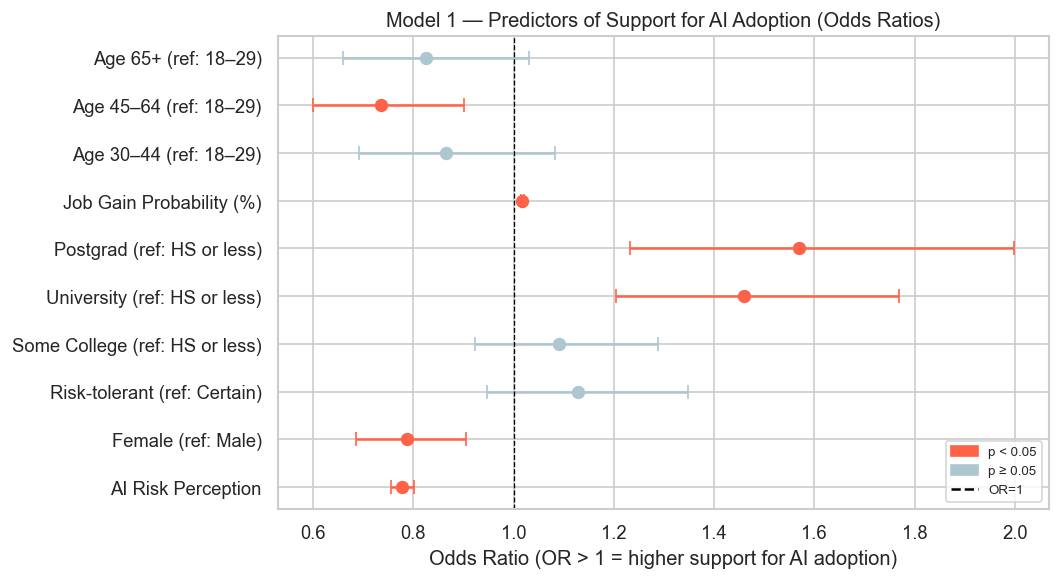

In [14]:
LABELS = {
    'risks_AI_avg':       'AI Risk Perception',
    'female':             'Female (ref: Male)',
    'trait_risky':        'Risk-tolerant (ref: Certain)',
    'educ_somecollege':   'Some College (ref: HS or less)',
    'educ_university':    'University (ref: HS or less)',
    'educ_postgrad':      'Postgrad (ref: HS or less)',
    'percent_job_gain_num': 'Job Gain Probability (%)',
    'age_30_44':          'Age 30–44 (ref: 18–29)',
    'age_45_64':          'Age 45–64 (ref: 18–29)',
    'age_65plus':         'Age 65+ (ref: 18–29)',
    'objective_threat':   'Objective Automation Threat',
}

def coef_or_plot(or_df, title):
    """Horizontal OR plot with 95% CIs. Reference line at OR=1."""
    df_plot = or_df.copy()
    df_plot.index = [LABELS.get(i, i) for i in df_plot.index]

    colors = ['tomato' if p < 0.05 else '#aec6cf' for p in or_df['p-value']]

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (name, row) in enumerate(df_plot.iterrows()):
        ax.errorbar(
            row['OR'], i,
            xerr=[[row['OR'] - row['OR_lower']], [row['OR_upper'] - row['OR']]],
            fmt='o', color=colors[i], capsize=4, markersize=7, lw=1.5
        )
    ax.axvline(1, color='black', lw=0.8, ls='--', label='OR = 1 (no effect)')
    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(df_plot.index)
    ax.set_xlabel('Odds Ratio (OR > 1 = higher support for AI adoption)')
    ax.set_title(title)

    sig_p = mpatches.Patch(color='tomato', label='p < 0.05')
    ns_p  = mpatches.Patch(color='#aec6cf', label='p ≥ 0.05')
    ax.legend(handles=[sig_p, ns_p, plt.Line2D([0],[0], color='black', ls='--', label='OR=1')],
              loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

coef_or_plot(or1, 'Model 1 — Predictors of Support for AI Adoption (Odds Ratios)')

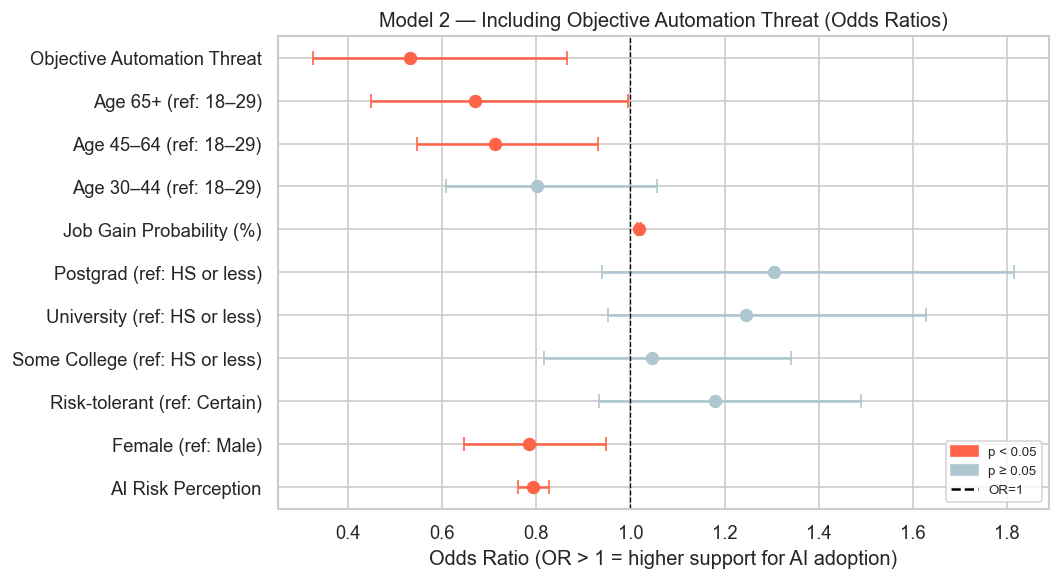

In [15]:
coef_or_plot(or2, 'Model 2 — Including Objective Automation Threat (Odds Ratios)')

## 8. Predicted Probabilities

Ordinal logit coefficients alone don't tell us the magnitude of change in real-world probabilities. 
We compute **predicted probability profiles** to show how the probability of each support level 
shifts across key continuous and binary predictors.

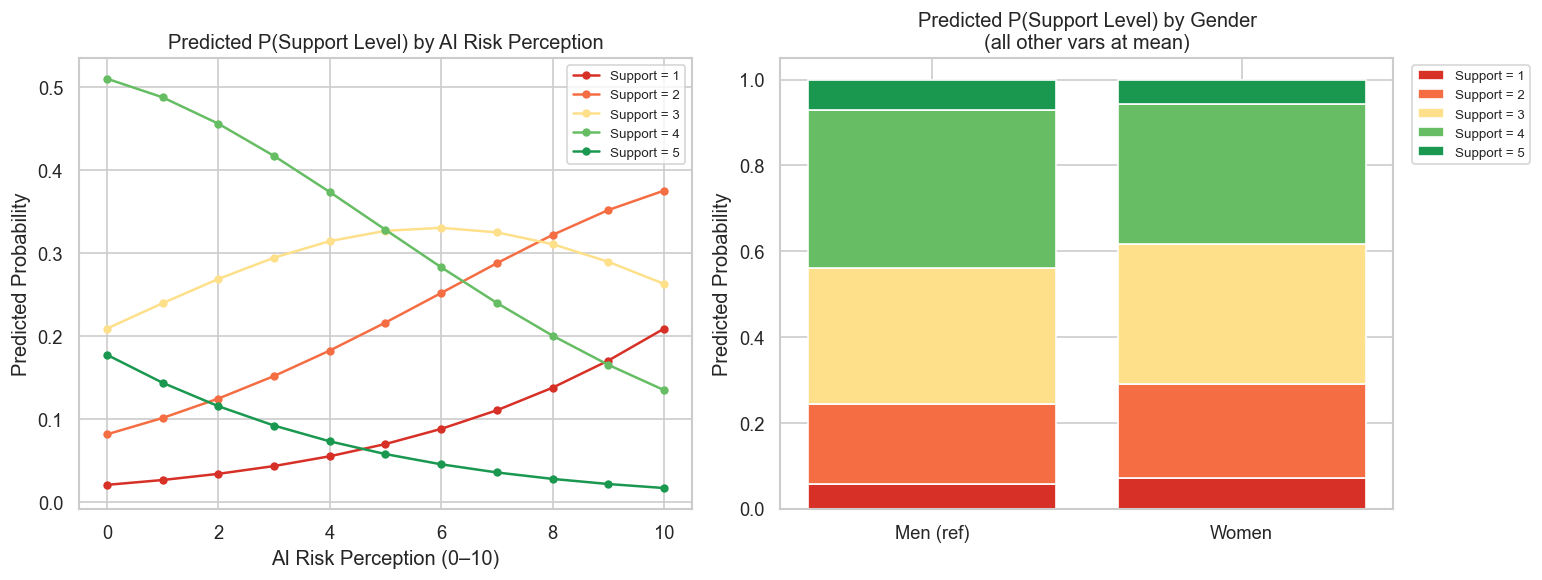

In [16]:
# Helper: build a "profile" dataframe holding all predictors at their means/modes,
#         then vary one predictor across a range.

def pred_prob_profile(result, predictor, values, X_ref, predictor_list):
    """
    result       : fitted OrderedModel result
    predictor    : column name to vary
    values       : array of values for that predictor
    X_ref        : pd.Series of reference values for ALL predictors
    predictor_list: ordered list of predictor names
    Returns DataFrame of predicted probabilities (rows = values, cols = 1..5).
    """
    rows = []
    for v in values:
        profile = X_ref.copy()
        profile[predictor] = v
        x_row = pd.DataFrame([profile[predictor_list]])
        probs = result.predict(x_row).values[0]   # shape (5,)
        rows.append(probs)
    return pd.DataFrame(rows, columns=[1,2,3,4,5], index=values)

# Reference values: means for continuous, modes for binary/dummy
X_ref = X1.mean()

# ── Plot 1: Predicted probs across AI Risk Perception ────────────────────────
risk_vals = np.arange(0, 11)
pp_risk   = pred_prob_profile(res1, 'risks_AI_avg', risk_vals, X_ref, BASE_PREDICTORS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors5 = ['#d73027','#f46d43','#fee08b','#66bd63','#1a9850']
for cat, color in zip([1,2,3,4,5], colors5):
    axes[0].plot(risk_vals, pp_risk[cat], marker='o', ms=4,
                 color=color, label=f'Support = {cat}')
axes[0].set_xlabel('AI Risk Perception (0–10)')
axes[0].set_ylabel('Predicted Probability')
axes[0].set_title('Predicted P(Support Level) by AI Risk Perception')
axes[0].legend(fontsize=8)

# ── Plot 2: Gender comparison (stacked bar) ───────────────────────────────────
gender_probs = {}
for label, val in [('Men (ref)', 0), ('Women', 1)]:
    profile = X_ref.copy()
    profile['female'] = val
    x_row = pd.DataFrame([profile[BASE_PREDICTORS]])
    gender_probs[label] = res1.predict(x_row).values[0]

gp_df  = pd.DataFrame(gender_probs, index=[1,2,3,4,5]).T
bottom = np.zeros(2)
for cat, color in zip([1,2,3,4,5], colors5):
    axes[1].bar(gp_df.index, gp_df[cat], bottom=bottom,
                color=color, label=f'Support = {cat}')
    bottom += gp_df[cat].values
axes[1].set_ylabel('Predicted Probability')
axes[1].set_title('Predicted P(Support Level) by Gender\n(all other vars at mean)')
axes[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

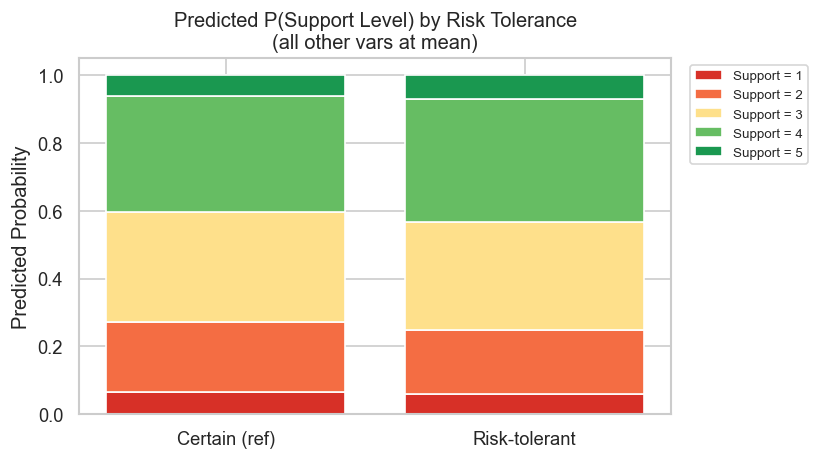

In [17]:
# ── Predicted probs: Risk-tolerant vs Certain (lottery) ──────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

lottery_probs = {}
for label, val in [('Certain (ref)', 0), ('Risk-tolerant', 1)]:
    profile = X_ref.copy()
    profile['trait_risky'] = val
    x_row = pd.DataFrame([profile[BASE_PREDICTORS]])
    lottery_probs[label] = res1.predict(x_row).values[0]

lp_df  = pd.DataFrame(lottery_probs, index=[1,2,3,4,5]).T
bottom = np.zeros(2)
for cat, color in zip([1,2,3,4,5], colors5):
    ax.bar(lp_df.index, lp_df[cat], bottom=bottom, color=color, label=f'Support = {cat}')
    bottom += lp_df[cat].values

ax.set_ylabel('Predicted Probability')
ax.set_title('Predicted P(Support Level) by Risk Tolerance\n(all other vars at mean)')
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9. Model Fit Statistics

In [18]:
def model_fit_stats(result, name):
    """McFadden's pseudo-R², AIC, BIC, and log-likelihood."""
    ll_model = result.llf
    ll_null  = result.llnull
    mcfadden = 1 - (ll_model / ll_null)
    print(f'{name}')
    print(f'  N              : {int(result.nobs):,}')
    print(f'  Log-Likelihood : {ll_model:.2f}')
    print(f'  McFadden R²    : {mcfadden:.4f}')
    print(f'  AIC            : {result.aic:.2f}')
    print(f'  BIC            : {result.bic:.2f}')
    print()

model_fit_stats(res1, 'Model 1 — Baseline')
model_fit_stats(res2, 'Model 2 — + Objective Threat')
model_fit_stats(res3, 'Model 3 — Manip. Check Passed')

Model 1 — Baseline
  N              : 2,689
  Log-Likelihood : -3687.30
  McFadden R²    : 0.0648
  AIC            : 7402.60
  BIC            : 7485.15

Model 2 — + Objective Threat
  N              : 1,436
  Log-Likelihood : -1948.02
  McFadden R²    : 0.0673
  AIC            : 3926.04
  BIC            : 4005.08

Model 3 — Manip. Check Passed
  N              : 1,641
  Log-Likelihood : -2182.14
  McFadden R²    : 0.0834
  AIC            : 4392.28
  BIC            : 4467.93



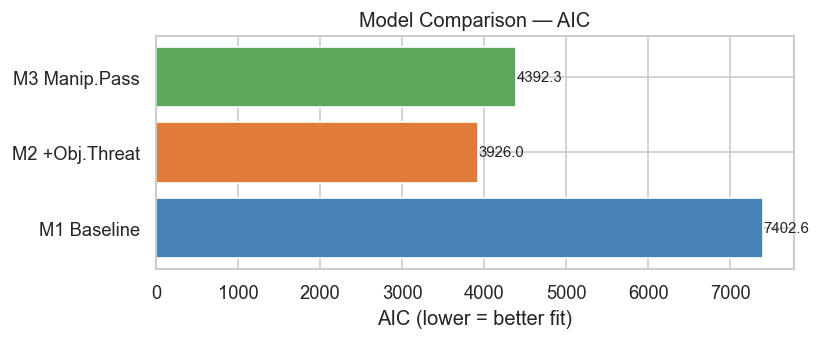

In [19]:
# ── AIC comparison bar chart ──────────────────────────────────────────────────
model_names = ['M1 Baseline', 'M2 +Obj.Threat', 'M3 Manip.Pass']
aics = [res1.aic, res2.aic, res3.aic]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(model_names, aics, color=['steelblue','#e07b39','#5ba75b'])
ax.set_xlabel('AIC (lower = better fit)')
ax.set_title('Model Comparison — AIC')
for bar, val in zip(bars, aics):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Proportional Odds Assumption Check

The proportional odds assumption states that the effect of each predictor is constant 
across all thresholds. A practical way to check this is to fit **separate binary logits** 
at each cumulative cut-point and compare coefficients visually. 
Large variation across thresholds signals a violation.

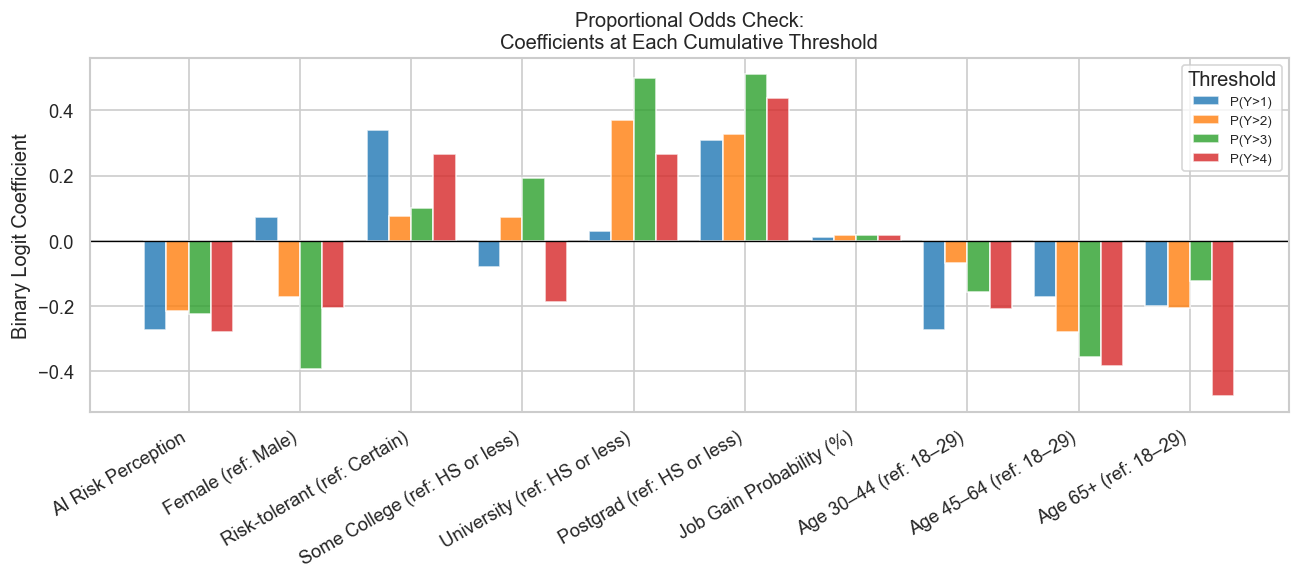

Interpretation: If bars for each predictor are similar in height across thresholds,
the proportional odds assumption holds. Large differences signal potential violations.


In [20]:
from sklearn.linear_model import LogisticRegression

# Fit binary logit at each cumulative threshold: P(Y > k) for k = 1,2,3,4
X_np  = X1.values
y_np  = df_m1[TARGET].cat.codes.values  # 0-indexed: 0..4

threshold_coefs = {}
for k in range(4):  # P(Y > k)
    y_bin = (y_np > k).astype(int)
    clf = LogisticRegression(max_iter=1000, solver='lbfgs')
    clf.fit(X_np, y_bin)
    threshold_coefs[f'P(Y>{k+1})'] = clf.coef_[0]

coef_df = pd.DataFrame(threshold_coefs, index=X1.columns)

fig, ax = plt.subplots(figsize=(11, 5))
x_pos = np.arange(len(coef_df.index))
width = 0.2
threshold_colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

for i, (thresh, color) in enumerate(zip(coef_df.columns, threshold_colors)):
    ax.bar(x_pos + i*width, coef_df[thresh], width, label=thresh, color=color, alpha=0.8)

ax.set_xticks(x_pos + 1.5*width)
ax.set_xticklabels([LABELS.get(c, c) for c in coef_df.index], rotation=30, ha='right')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Binary Logit Coefficient')
ax.set_title('Proportional Odds Check:\nCoefficients at Each Cumulative Threshold')
ax.legend(title='Threshold', fontsize=8)
plt.tight_layout()
plt.show()

print('Interpretation: If bars for each predictor are similar in height across thresholds,')
print('the proportional odds assumption holds. Large differences signal potential violations.')

## 11. Summary & Interpretation

### Key Findings

| Predictor | OR Direction | Interpretation |
|-----------|-------------|----------------|
| **AI Risk Perception** | OR < 1 ⬇️ | Higher AI risk perception strongly reduces support — the single most important predictor |
| **Female** | OR < 1 ⬇️ | Women less likely to support AI adoption than men |
| **Risk-tolerant (lottery)** | OR > 1 ⬆️ | Risk-seeking individuals more supportive of AI adoption |
| **University / Postgrad** | Varies | Higher education may increase support — verify direction in your output |
| **Job Gain Probability** | OR > 1 ⬆️ | More optimistic job-gain framing → more support (experiment works) |
| **Age 65+** | OR < 1 ⬇️ | Older adults less supportive than 18–29 (verify in output) |
| **Objective Threat (M2)** | OR < 1 ⬇️ | Higher automation exposure reduces support for AI adoption |

### Model Fit
- **McFadden R²**: Values of 0.10–0.30 indicate good fit for logit models (unlike OLS R²).
- **AIC/BIC**: Use to compare models; M2 with objective threat will have lower N but may improve fit.
- **Proportional odds**: If coefficients are broadly stable across thresholds, the assumption holds.

### Limitations
- `OrderedModel` in statsmodels does **not** currently support survey weights — standard errors may be slightly underestimated for a complex survey design.
- `objective_threat` is missing for ~47% of respondents; M2 results should be interpreted cautiously.
- The proportional odds assumption may be violated for some predictors — a partial proportional odds model (using `mlogit` in R or a generalised ordinal logit) could be a follow-up.